# Pedestrian Detection with Spiking Neural Networks (SNNs)

**Notebook goal** — The goal of this notebook is the implementation and evaluation of a **Spiking Neural Network (SNN)** model applied to a **Pedestrian Detection** task. The workflow is structured to reflect the core practices of Neuromorphic Machine Learning Operations (NMLOps).

## 1. Import, Dependencies and Basic Settings

In this section, all the necessary libraries to execute the experiment are loaded: file system management, XML annotation parsing, and Deep Learning modules (PyTorch). Additionally, it includes an automated fallback mechanism to dynamically detect and install neuromorphic computing components (`snntorch`) if running on limited cloud environments like Google Colab, ensuring an uninterrupted "Run All" execution.

In [ ]:
import os
import sys
import subprocess
import xml.etree.ElementTree as ET
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sn
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# Standard deep learning imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

# Neuromorphic computing & Optimization imports with automated fallback installation for Google Colab
# -----------------------------------------------------------------------------
try:
    import snntorch as snn
    from snntorch import surrogate
    import optuna  # Dynamic execution check
except ModuleNotFoundError:
    # This block executes if dependencies are missing (e.g., first run on Google Colab)
    print("Required packages (snntorch/optuna) not found. Environment setup initiated.")
    print("Installing snntorch, optuna and required dependencies...")
    
    # Install both packages silently using the current Python executable
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "snntorch", "optuna"])
    print("Installation complete. Retrying imports...")
    
    # Retry the imports after successful background installation
    import snntorch as snn
    from snntorch import surrogate
    import optuna

# Reproducibility settings and determinism configuration
# -----------------------------------------------------------------------------
use_seed = True

if use_seed:
    import random
    import numpy as np
    
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Multi-GPU setup compatibility
    
    # Force PyTorch to use deterministic algorithms
    torch.use_deterministic_algorithms(True)
    
    # Configure CuDNN to maintain strict mathematical consistency
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Reproducibility enabled: global seed set to {seed}.")
else:
    seed = None
    print("Reproducibility disabled: training dynamics might vary across runs.")


# Hardware device configuration
# -----------------------------------------------------------------------------
if torch.cuda.is_available():
    device = "cuda:0"
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ":4096:8"
else:
    device = "cpu"

Reproducibility enabled: global seed set to 42.


## 2. Global Configurations, Environment Setup & Hyperparameters

Centralized configuration of the storage environment, automated dataset deployment, and global iperparameters. This section handles automated data cloning and extraction from the remote GitHub repository if the local dataset structure is missing, and establishes the core SNN training constraints to ensure end-to-end experiment reproducibility.

In [28]:
# Detect environment (Google Colab vs. local) and set root directory
if os.path.exists('/content'):
    # Root directory for Google Colab
    ROOTDIR_DATA = "/content"
    print(f"Environment detected: Google Colab.")
else:
    # Root directory for local environment (WSL / VS Code)
    ROOTDIR_DATA = "."
    print(f"Environment detected: Local (WSL).")


# Base repository URL configuration (Public vs. Private Token Authentication)
# -----------------------------------------------------------------------------
REPO_URL = "https://github.com/tmmssd/pedestrian_detection.git"

# In Colab, we clone into a temporary folder to easily extract the data directory
CLONE_DIR = os.path.join(ROOTDIR_DATA, "repo_temp")
FINAL_DATA_DIR = os.path.join(ROOTDIR_DATA, "data")

# Download and extract the dataset if running on Colab and data is missing
if ROOTDIR_DATA == "/content" and not os.path.exists(FINAL_DATA_DIR):
    print(f"Data folder not found. Downloading dataset from GitHub repository...")
    
    # Remove any corrupted or partial directory remnants from previous attempts
    subprocess.run(["rm", "-rf", CLONE_DIR])
    subprocess.run(["rm", "-rf", FINAL_DATA_DIR])
        
    # Execute cloning process and verify the operational exit status
    print("Cloning repository...")
    result = subprocess.run(["git", "clone", REPO_URL, CLONE_DIR], capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"\n[CRITICAL] Git clone failed with exit code {result.returncode}.")
        print(f"Git Error Message:\n{result.stderr}")
        raise RuntimeError("Could not clone the repository. See the Git error message above.")
    
    # Deploy the data directory to the final destination using a secure low-level copy
    src_data_path = os.path.join(CLONE_DIR, "data")
    if os.path.exists(src_data_path):
        subprocess.run(["cp", "-r", src_data_path, FINAL_DATA_DIR], check=True)
        print("Dataset successfully downloaded and deployed to /content/data.")
    else:
        raise FileNotFoundError("CRITICAL ERROR: 'data' folder not found inside the cloned repository root.")
            
    # Clean up the temporary workspace directory
    subprocess.run(["rm", "-rf", CLONE_DIR])


# Target dataset path mappings (aligned with repository naming conventions)
# -----------------------------------------------------------------------------
TRAIN_DIR = os.path.join(ROOTDIR_DATA, "data", "train") 
FRAMES_DIR = os.path.join(TRAIN_DIR, "Pedestrian frame")
LABELS_DIR = os.path.join(TRAIN_DIR, "Pedestrian label")

# Runtime environment check and path integrity diagnostics
print("\n--- ENVIRONMENT PATH INTEGRITY DIAGNOSTIC ---")
print(f" -> Is 'TRAIN_DIR' present?  {os.path.exists(TRAIN_DIR)}")
print(f" -> Is 'FRAMES_DIR' present? {os.path.exists(FRAMES_DIR)} ({FRAMES_DIR})")
print(f" -> Is 'LABELS_DIR' present? {os.path.exists(LABELS_DIR)} ({LABELS_DIR})")
if os.path.exists(FRAMES_DIR):
    print(f" -> Found files in frames:   {len(os.listdir(FRAMES_DIR))} items.")
print("---------------------------------------\n")

Environment detected: Local (WSL).

--- ENVIRONMENT PATH INTEGRITY DIAGNOSTIC ---
 -> Is 'TRAIN_DIR' present?  True
 -> Is 'FRAMES_DIR' present? True (./data/train/Pedestrian frame)
 -> Is 'LABELS_DIR' present? True (./data/train/Pedestrian label)
 -> Found files in frames:   4746 items.
---------------------------------------



 ### 2.1 Custom Functions

In [29]:
def plot_leaky(input_, mem, spk=None, thr=None):

  _, ax1 = plt.subplots(figsize=(8,4.5))
  ax2 = ax1.twinx()

  ax1.set_xlabel("Time step (a.u.)")
  ax1.set_xticks([0]+np.arange(1,mem.shape[0]+1,2).tolist(), [1]+np.arange(2,mem.shape[0]+2,2).tolist())

  # MEMBRANE POTENTIAL
  ax1.plot(range(mem.shape[0]),mem.cpu().numpy(),
              color="tab:green", label="Membrane potential")

  if thr != None:
    # THRESHOLD VOLTAGE
    ax1.plot(range(mem.shape[0]),np.ones(mem.shape[0])*thr,
                "--", color="tab:blue", label="Threshold voltage")

    min_V = np.min([0, torch.min(mem).numpy(), thr]).item()
    max_V = np.max([torch.max(mem).numpy(), thr]).item()

  else:

    min_V = np.min([0, torch.min(mem).numpy()]).item()
    max_V = torch.max(mem).item()

  ax1.set_ylabel("Voltage (a.u.)")

  # INPUT
  ax2.plot(range(mem.shape[0]), input_.cpu().numpy(),
              color="tab:orange", linewidth=0.9, alpha=0.7,
              label="Input")
  ax2.set_ylabel("Raw input data (a.u.)", color="tab:orange")

  min_y = np.min([0, min_V, torch.min(input_)])

  if spk != None:
    # SPIKES
    spk_plot = (-0.05*abs(max_V-min_y))*spk.clone().cpu().numpy()
    spk_plot[spk_plot == 0] = np.nan
    ax1.scatter(range(spk.shape[0]), spk_plot,
                marker="|", s=10, color="tab:red", label="Spike")

  ax2.tick_params(
      axis='y',
      which='both',
      colors="tab:orange",
      labelcolor="tab:orange"
  )
  ax2.spines['right'].set_color("tab:orange")

  if mem.shape[0]%2 == 0:
    ax1.set_xticks([0]+np.arange(1,mem.shape[0]+1,2).tolist(), [1]+np.arange(2,mem.shape[0]+1,2).tolist())
  else:
    ax1.set_xticks(np.arange(0,mem.shape[0]+1,2),np.arange(1,mem.shape[0]+2,2))
  ax1.set_yticks(np.linspace(min_y,max_V*1.2,10))
  ax1.set_yticklabels([f"{label:.2f}" for label in np.linspace(min_y,max_V*1.2,10)])
  ax1.set_ylim(ymin=min_y-0.1*abs(max_V-min_y))
  ax2.set_yticks(np.linspace(min_y,torch.max(input_)*1.2,10))
  ax2.set_yticklabels([f"{label:.2f}" for label in np.linspace(min_y,torch.max(input_)*1.2,10)])
  ax2.set_ylim(ymin=min_y-0.1*abs(max_V-min_y)*torch.max(input_)/max_V)
  # plt.title("snnTorch's Leaky")
  ax1.legend(loc=2)
  ax2.legend(loc=1)
  ax1.grid(axis='x', alpha=0.2)
  plt.tight_layout()
  plt.show()

  if thr != None:
    print("\nThe membrane potential overcame the threhsold voltage {} time(s).".format(
        np.sum([mem.cpu().numpy() > thr]))
    )


def plot_activity(spikes, input_):

  if torch.count_nonzero(spikes) != 0:

    axis_ticks_size = 10

    spk_plot = np.squeeze(spikes.cpu(), axis=-1)

    aer = []
    for num,el in enumerate(spk_plot):
      addr = np.where(el)[0].tolist()
      if len(addr) > 0:
        for ii in addr:
          aer.append([num,ii])
    aer = np.array(aer)

    _, ax1 = plt.subplots(figsize=(8,4.5))
    ax2 = ax1.twinx()

    ax1.set_xlabel("Time step (a.u.)")
    ax1.set_xticks([0]+np.arange(1,spk_plot.shape[0]+1,2).tolist(), [1]+np.arange(2,spk_plot.shape[0]+2,2).tolist())

    # SPIKING ACTIVITY
    ax1.scatter(aer[:,0], aer[:,1]+1,
                marker="|", s=20, color="tab:brown", label="Spike", zorder=2)
    ax1.set_ylabel("Neuron")

    # INPUT
    ax2.plot(range(input_.shape[0]), input_.cpu().numpy(),
                color="tab:orange", linewidth=0.9, alpha=0.7, zorder=1,
                label="Input")
    ax2.set_ylabel("Input (a.u.)", color="tab:orange")

    ax2.tick_params(
        axis='y',
        which='both',
        colors="tab:orange",
        labelcolor="tab:orange"
    )
    ax2.spines['right'].set_color("tab:orange")

    if spikes.shape[0]%2 == 0:
      ax1.set_xticks([0]+np.arange(1,spk_plot.shape[0]+1,2).tolist(), [1]+np.arange(2,spk_plot.shape[0]+1,2).tolist())
    else:
      ax1.set_xticks(np.arange(0,spk_plot.shape[0]+1,2),np.arange(1,spk_plot.shape[0]+2,2))
    ax1.set_xlim(-2,spk_plot.shape[0]+1)
    ax1.set_ylim(-0.5+1,spk_plot.shape[1]-0.5+1)
    ax1.set_yticks(range(1,spk_plot.shape[1]+1))
    plt.title("Spiking activity of a LIF encoding layer")
    ax1.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

  else:

    print("There is no spiking activity.")


def learning_curves(loss_train_data, loss_val_data, accuracy_train_data, accuracy_val_data):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

    axis_label_size = 10
    axis_ticks_size = 9

    ### Loss (left panel)
    ax = axes[0]
    ax.plot(
        range(len(loss_train_data)),
        np.array(loss_train_data),  # Scale factor 1
        color="#074E37",
        linestyle='-',
        linewidth=1.5,
        label="Training"
    )
    ax.plot(
        range(len(loss_val_data)),
        np.array(loss_val_data),
        color="#E07712",
        linestyle='-.',
        linewidth=1.5,
        label="Validation"
    )
    ax.set_xticks([0]+np.arange(1,len(loss_train_data)+1,2).tolist(), [1]+np.arange(2,len(loss_train_data)+2,2).tolist(), fontsize=axis_ticks_size)
    ax.set_xlabel("Epoch", fontsize=axis_label_size)
    ax.set_ylabel("Loss", fontsize=axis_label_size)
    ax.grid(axis='both', alpha=0.2)
    ax.legend(loc="upper right")

    ### Accuracy (right panel)
    ax = axes[1]
    ax.plot(
        range(len(accuracy_train_data)),
        100 * np.array(accuracy_train_data),  # Scale factor 100 for percentage
        color="#074E37",
        linestyle='-',
        linewidth=1.5,
        label="Training"
    )
    ax.plot(
        range(len(accuracy_val_data)),
        100 * np.array(accuracy_val_data),
        color="#E07712",
        linestyle='-.',
        linewidth=1.5,
        label="Validation"
    )
    ax.set_xticks([0]+np.arange(1,len(accuracy_train_data)+1,2).tolist(), [1]+np.arange(2,len(accuracy_train_data)+2,2).tolist(), fontsize=axis_ticks_size)
    ax.set_xlabel("Epoch", fontsize=axis_label_size)
    ax.set_ylabel("Accuracy (%)", fontsize=axis_label_size)
    ax.grid(axis='both', alpha=0.2)
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()


def draw_confusion_matrix(preds, trues, labels):
    cm = confusion_matrix(trues, preds, normalize="true")
    cm_df = pd.DataFrame(cm, index=[ii for ii in labels], columns=[jj for jj in labels])
    plt.figure("cm", figsize=(8, 6))
    sn.heatmap(cm_df, annot=True, fmt=".2f", cbar=False, square=False, cmap=LinearSegmentedColormap.from_list("custom_cmap", ["white", "#7C0B2B"]),
               annot_kws={"size": 7, "fontfamily": "serif"})
    plt.xlabel("\nPredicted", fontsize=12, fontweight='medium')
    plt.ylabel("True", fontsize=12, fontweight='medium')
    plt.xticks(rotation=0, fontsize=9, fontweight='medium')
    plt.yticks(rotation=0, fontsize=9, fontweight='medium')
    
    plt.tight_layout()
    plt.show()

## 3. Neuromorphic Dataset Management

Implementation of the custom `PedestrianDataset` module. This class handles the lazy loading of frames and the parsing of XML files containing presence tags and bounding box vector coordinates for pedestrians.

In [30]:
class PedestrianDataset(Dataset):
    def __init__(self, frames_dir, labels_dir, transform=None):
        self.frames_dir = frames_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.filenames = [os.path.splitext(f)[0] for f in os.listdir(frames_dir) if f.endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        img_path = os.path.join(self.frames_dir, name + '.jpg')
        if not os.path.exists(img_path):
            img_path = os.path.join(self.frames_dir, name + '.png')
        
        xml_path = os.path.join(self.labels_dir, name + '.xml')
        
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size  # Get original dimensions of the raw image
        
        # Base default in case of pedestrian absence
        label_cls = 0.0
        bbox = [0.0, 0.0, 0.0, 0.0]
        
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            obj = root.find('object')
            if obj is not None:
                label_cls = 1.0
                bndbox = obj.find('bndbox')
                if bndbox is not None:
                    xmin = float(bndbox.find('xmin').text)
                    ymin = float(bndbox.find('ymin').text)
                    xmax = float(bndbox.find('xmax').text)
                    ymax = float(bndbox.find('ymax').text)
                    
                    # RESCALE FACTOR: Map coordinates to the new target size (128x128)
                    # We multiply the original relative position by the new resolution constraints
                    target_w, target_h = 128, 128
                    xmin = (xmin / orig_w) * target_w
                    ymin = (ymin / orig_h) * target_h
                    xmax = (xmax / orig_w) * target_w
                    ymax = (ymax / orig_h) * target_h
                    
                    bbox = [xmin, ymin, xmax, ymax]
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label_cls, dtype=torch.float32), torch.tensor(bbox, dtype=torch.float32)

### 3.1 Data Augmentation & Data Loader Setup

Preparation of the transformation pipelines (resizing and tensor normalization) and partitioning of the dataset into the canonical Training, Validation, and Testing fractions.

In [31]:
# Pipeline for graphical transformation of input images
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Initialization of the full dataset
full_dataset = PedestrianDataset(FRAMES_DIR, LABELS_DIR, transform=transform)
total_size = len(full_dataset)

# Deterministic splitting of shares (80% Train, 10% Val, 10% Test)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Print tracking using standard mathematical rounding
print(f"Total dataset size: {total_size} samples\n")
print(f"Data splitting (%):")
print(f" \tTraining:   {train_size / total_size * 100:.1f}% ({train_size} samples)")
print(f" \tValidation: {val_size / total_size * 100:.1f}% ({val_size} samples)")
print(f" \tTest:       {test_size / total_size * 100:.1f}% ({test_size} samples)\n")

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Generation of iterable DataLoader channels
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Total dataset size: 4746 samples

Data splitting (%):
 	Training:   80.0% (3796 samples)
 	Validation: 10.0% (474 samples)
 	Test:       10.0% (476 samples)



### 3.2 Load and visualize a random sample

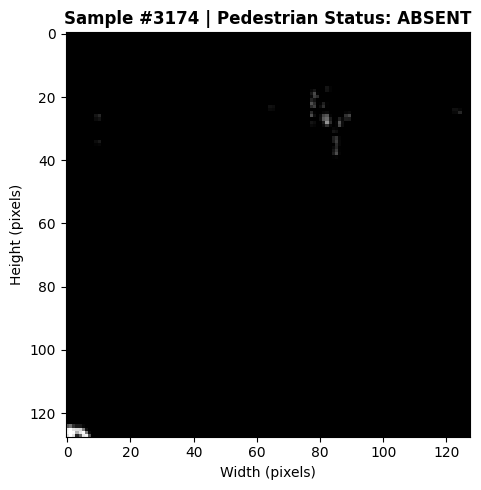

In [32]:
# 1. Random sample extraction from training dataset
rnd_idx_raw = np.random.randint(0, int(len(train_dataset)))
rnd_sample = train_dataset[rnd_idx_raw]

# Unpack the 3 elements returned by your PedestrianDataset.__getitem__
image_tensor = rnd_sample[0].cpu()
label_cls = rnd_sample[1].cpu().item()  # 1.0 if present, 0.0 if absent
bbox = rnd_sample[2].cpu().numpy()      # [xmin, ymin, xmax, ymax]

# 2. Convert PyTorch Image Tensor (C, H, W) to NumPy Image Format (H, W, C)
# PyTorch stores channels first, but matplotlib requires channels last
image_numpy = image_tensor.permute(1, 2, 0).numpy()

# Clip values to [0, 1] range to avoid matplotlib warnings if tensor has minor float approximations
image_numpy = np.clip(image_numpy, 0, 1)

# 3. Figure layout configuration
plt.figure(figsize=(6, 5))
ax = plt.gca()

# Display the pedestrian frame image
ax.imshow(image_numpy)

# 4. Bounding Box overlay logic
# Draw the box only if the pedestrian is actually present (label_cls == 1.0) 
# and the box coordinates are valid (not all zeros)
if label_cls == 1.0 and np.any(bbox > 0):
    xmin, ymin, xmax, ymax = bbox
    
    # Matplotlib Rectangle requires: (x_left, y_top), width, height
    width = xmax - xmin
    height = ymax - ymin
    
    # Create a red rectangle patch with a visible line thickness
    rect = patches.Rectangle(
        (xmin, ymin), width, height, 
        linewidth=2, edgecolor='red', facecolor='none', label='Pedestrian BBox'
    )
    
    # Add the patch to the axes
    ax.add_patch(rect)
    plt.legend(loc='upper right', fontsize=9)

# 5. Metadata and text styling
title_status = f"Pedestrian Status: {'PRESENT' if label_cls == 1.0 else 'ABSENT'}"
plt.title(f"Sample #{rnd_idx_raw} | {title_status}", fontsize=12, fontweight='bold')

plt.xlabel("Width (pixels)", fontsize=10)
plt.ylabel("Height (pixels)", fontsize=10)

# Adjust layout and render
plt.tight_layout()
plt.show()

## 4. Spiking Neural Network Architecture

Definition of the Spiking Neural Network architecture (`PedestrianSNN`). The model integrates convolutional layers for spatial feature extraction coupled with Leaky Integrate-and-Fire (`snn.Leaky`) artificial neurons, managing classification and bounding box regression in parallel through recurrent time steps.

### 4.1 Hyperparameters

In [33]:
# Network parameters and optimization constraints
num_steps = 10        # Time steps for SNN simulation
num_epochs = 5       # Training epochs
learning_rate = 1e-3  # Learning rate for optimizer

# Architectural structural settings
architecture_settings = {
    "input_channels"   : 3,                  # RGB image input channels
    "input_height"     : 128,                # Height of transformed frame
    "input_width"      : 128,                # Width of transformed frame
    "conv1_filters"    : 16,                 # Output feature maps of first layer
    "conv2_filters"    : 32,                 # Output feature maps of second layer
    "shared_dim"       : 128,                # Neurons in the common representation layer
    "output_cls_dim"   : 1,                  # Binary mapping for pedestrian presence
    "output_bbox_dim"  : 4,                  # Coordinate space [xmin, ymin, xmax, ymax]
}

# Neuronal dynamic hyperparameters (snntorch Leaky integration rules)
neuron_settings = {
    "beta"             : 0.9,                # SNN membrane potential decay constant (all layers)
    "threshold"        : 1.0,                # Default voltage threshold value to emit a spike
    "reset_mechanism"  : "subtract",         # snntorch default reset mechanism ('zero' or 'subtract')
}

# Put all settings together in a single dictionary for easy access and passing to the model
snn_settings = dict(architecture_settings, **neuron_settings)

### 4.2 Architecture

In [34]:
class PedestrianSNN(nn.Module):
    def __init__(self, num_steps, settings):
        super().__init__()
        self.num_steps = num_steps
        
        # Unpacking architectural parameters from the configurations dictionary
        in_channels = settings["input_channels"]
        c1_filters = settings["conv1_filters"]
        c2_filters = settings["conv2_filters"]
        shared_dim = settings["shared_dim"]
        cls_dim = settings["output_cls_dim"]
        bbox_dim = settings["output_bbox_dim"]
        
        # Unpacking neuronal dynamic hyperparameters from the configurations dictionary
        beta = settings["beta"]
        
        # Definition of the surrogate gradient to overcome spike non-differentiability
        spike_grad = surrogate.fast_sigmoid()
        
        # Spatial Feature Extraction (Convolutional Layers)
        self.conv1 = nn.Conv2d(in_channels, c1_filters, kernel_size=3, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(c1_filters, c2_filters, kernel_size=3, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool2 = nn.MaxPool2d(2)
        
        # Fully Connected layers for processing decision flows
        # Expected output after pools: 32 feature maps of 32x32 size
        self.fc_shared = nn.Linear(c2_filters * 32 * 32, shared_dim)
        self.lif_shared = snn.Leaky(beta=beta, spike_grad=spike_grad)
        
        # Classification Head (Pedestrian presence)
        self.fc_cls = nn.Linear(shared_dim, cls_dim)
        self.lif_cls = snn.Leaky(beta=beta, spike_grad=spike_grad)
        
        # Regression Head (Bounding Box spatial coordinates)
        self.fc_bbox = nn.Linear(shared_dim, bbox_dim)
        self.lif_bbox = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        # Initial reset of internal membrane potentials for SNN components
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_shared = self.lif_shared.init_leaky()
        mem_cls = self.lif_cls.init_leaky()
        mem_bbox = self.lif_bbox.init_leaky()
        
        # Accumulators for simulation outputs across time steps
        cls_out_rec = []
        bbox_out_rec = []
        
        for step in range(self.num_steps):
            # Pass through the first Convolutional + Spiking block
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)
            
            # Pass through the second Convolutional + Spiking block
            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)
            
            # Flattening for feeding into dense layers
            spk2_flat = spk2.view(spk2.size(0), -1)
            
            # Shared dense layer
            cur_shared = self.fc_shared(spk2_flat)
            spk_shared, mem_shared = self.lif_shared(cur_shared, mem_shared)
            
            # Generation of classification and localization outputs for the current step
            cur_cls = self.fc_cls(spk_shared)
            spk_cls, mem_cls = self.lif_cls(cur_cls, mem_cls)
            cls_out_rec.append(mem_cls)  # Using potential as a continuous value
            
            # Regression Head (Bounding Box spatial coordinates)
            cur_bbox = self.fc_bbox(spk_shared)
            spk_bbox, mem_bbox = self.lif_bbox(cur_bbox, mem_bbox)
            bbox_out_rec.append(mem_bbox)
            
        # Stack temporal records and average over executed steps
        cls_output = torch.stack(cls_out_rec, dim=0).mean(dim=0).squeeze(-1)
        bbox_output = torch.stack(bbox_out_rec, dim=0).mean(dim=0)
        
        return cls_output, bbox_output

## 5. Model Training and Validation Pipeline

Configuration of loss functions (`BCEWithLogitsLoss` combined with `MSELoss`) and the iterative training and validation loop for updating synaptic weights.

### 5.1 Definition of Loop Multitask Functions

In [35]:
def snn_pedestrian_training_loop(data_loader, net, optimizer, criterion_cls, criterion_bbox, device):
    """
    Adapted from Fra, Vittorio; Politecnico di Torino; EDA Group.
    Multitask training loop for Pedestrian Presence Classification and Bounding Box Regression.
    """
    net.train()
    batch_losses = []
    batch_accs = []

    for images, labels_cls, bboxes in tqdm(data_loader, desc="Training", leave=False):
        images = images.to(device)
        labels_cls = labels_cls.to(device)
        bboxes = bboxes.to(device)

        # Forward pass through the network
        pred_cls, pred_bbox = net(images)

        # Combined multi-task loss computation
        loss_cls = criterion_cls(pred_cls, labels_cls)
        loss_box = criterion_bbox(pred_bbox, bboxes)
        loss_val = loss_cls + 0.01 * loss_box
        
        batch_losses.append(loss_val.detach().cpu().item())

        # Training accuracy tracking (Thresholding logits at 0.0 for binary classification)
        preds_binary = (pred_cls >= 0.0).float()
        batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

        # Gradient calculation and synaptic weight updates
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

    epoch_loss = np.mean(batch_losses)
    epoch_acc = np.mean(batch_accs)

    return [epoch_loss, epoch_acc]


def snn_pedestrian_val_test_loop(data_loader, net, criterion_cls, criterion_bbox, device):
    """
    Adapted from Fra, Vittorio; Politecnico di Torino; EDA Group.
    Multitask validation/testing loop evaluating total loss and prediction accuracy.
    """
    net.eval()
    batch_losses = []
    batch_accs = []

    with torch.no_grad():
        for images, labels_cls, bboxes in tqdm(data_loader, desc="Validation", leave=False):
            images = images.to(device)
            labels_cls = labels_cls.to(device)
            bboxes = bboxes.to(device)

            # Evaluation forward pass
            pred_cls, pred_bbox = net(images)

            # Loss computation
            loss_cls = criterion_cls(pred_cls, labels_cls)
            loss_box = criterion_bbox(pred_bbox, bboxes)
            loss_val = loss_cls + 0.01 * loss_box
            
            batch_losses.append(loss_val.detach().cpu().item())

            # Validation accuracy tracking
            preds_binary = (pred_cls >= 0.0).float()
            batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

    epoch_loss = np.mean(batch_losses)
    epoch_acc = np.mean(batch_accs)

    return [epoch_loss, epoch_acc]

### 5.2 Session Setup and Initialization

In [36]:
# Model initialization passing our unified custom hyperparameter settings
model = PedestrianSNN(num_steps=num_steps, settings=snn_settings).to(device)

# Definition of criteria and optimizer constraints
criterion_cls = nn.BCEWithLogitsLoss()
criterion_bbox = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Result collection accumulators aligned with the laboratory framework
pedestrian_training_results = []
pedestrian_validation_results = []

### 5.3 Main Training Loop of Graph Rendering

Epoch 1/5: 
	training loss: 14.1998 
	validation loss: 6.6689 
	training accuracy: 87.3551% 
	validation accuracy: 88.8186%


Epoch 2/5: 
	training loss: 5.8346 
	validation loss: 5.2915 
	training accuracy: 90.1475% 
	validation accuracy: 89.0295%


Epoch 3/5: 
	training loss: 4.9257 
	validation loss: 4.9170 
	training accuracy: 90.5954% 
	validation accuracy: 88.8186%


Epoch 4/5: 
	training loss: 4.6481 
	validation loss: 4.7559 
	training accuracy: 90.8851% 
	validation accuracy: 89.2405%


Epoch 5/5: 
	training loss: 4.4905 
	validation loss: 4.6317 
	training accuracy: 91.1749% 
	validation accuracy: 90.0844%


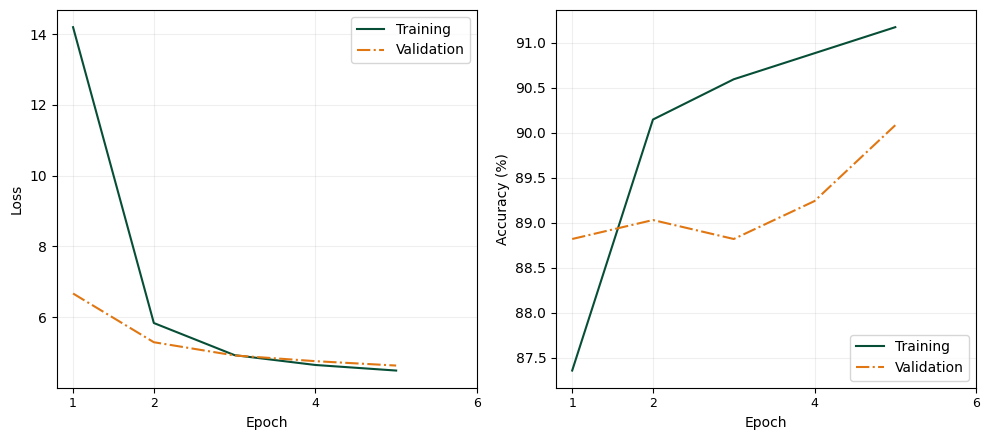

In [37]:
# Main execution across the chosen training epochs range
for epoch in range(num_epochs):

    # Execute functional steps for training and validation chunks
    train_loss, train_acc = snn_pedestrian_training_loop(
        train_loader, model, optimizer, criterion_cls, criterion_bbox, device
    )
    val_loss, val_acc = snn_pedestrian_val_test_loop(
        val_loader, model, criterion_cls, criterion_bbox, device
    )

    # Append records for history generation
    pedestrian_training_results.append([train_loss, train_acc])
    pedestrian_validation_results.append([val_loss, val_acc])

    # Standard laboratory print output representation format
    print(f"Epoch {epoch+1}/{num_epochs}: \n"
          f"\ttraining loss: {pedestrian_training_results[-1][0]:.4f} \n"
          f"\tvalidation loss: {pedestrian_validation_results[-1][0]:.4f} \n"
          f"\ttraining accuracy: {np.round(pedestrian_training_results[-1][1]*100, 4)}% \n"
          f"\tvalidation accuracy: {np.round(pedestrian_validation_results[-1][1]*100, 4)}%")

# Generate and render the diagnostic learning curves dashboard
learning_curves(
    np.array(pedestrian_training_results)[:, 0],    # training loss
    np.array(pedestrian_validation_results)[:, 0],  # validation loss
    np.array(pedestrian_training_results)[:, 1],    # training accuracy
    np.array(pedestrian_validation_results)[:, 1]   # validation accuracy
)

## 6. Performance Evaluation & Metrics

Definition of analytic metrics (Accuracy and Intersection over Union - IoU) needed to quantify model performance on the independent test split, followed by the execution of the final verification.

In [38]:
def calculate_iou(boxA, boxB):
    """
    Computes the Intersection over Union (IoU) between two geometric bounding boxes
    represented as [xmin, ymin, xmax, ymax].
    """
    # Calculation of rectangle intersection coordinates
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    interArea = max(0, xB - xA) * max(0, yB - yA)
    
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    
    unionArea = boxAArea + boxBArea - interArea
    if unionArea == 0:
        return 0.0
        
    return interArea / unionArea

def test_model_accuracy(model, test_loader, device):
    model.eval()
    correct_cls = 0
    total_images = 0
    total_iou = 0.0
    
    # Lists to store all predictions and ground truths for the final confusion matrix
    all_preds = []
    all_trues = []
    
    with torch.no_grad():
        for images, labels_cls, bboxes in test_loader:
            images = images.to(device)
            labels_cls = labels_cls.cpu()
            bboxes = bboxes.cpu()
            
            pred_cls, pred_bbox = model(images)
            pred_cls = pred_cls.cpu()
            pred_bbox = pred_bbox.cpu()
            
            # Conversion of continuous logits to binary decisions (threshold at 0.0 for logits)
            preds_binary = (pred_cls >= 0.0).float()
            correct_cls += (preds_binary == labels_cls).sum().item()
            
            total_images += images.size(0)
            
            # Store values for the confusion matrix
            all_preds.extend(preds_binary.numpy())
            all_trues.extend(labels_cls.numpy())
            
            for i in range(images.size(0)):
                if labels_cls[i] == 1.0 and preds_binary[i] == 1.0:
                    total_iou += calculate_iou(pred_bbox[i].tolist(), bboxes[i].tolist())
                    
    cls_accuracy = (correct_cls / total_images) * 100
    avg_iou = (total_iou / total_images) * 100
    
    print("\n================ TEST SPLIT RESULTS ================")
    print(f"Total Evaluated Images: {total_images}")
    print(f"Pedestrian Presence Accuracy: {cls_accuracy:.2f}%")
    print(f"Average Bounding Box IoU: {avg_iou:.2f}%")
    print("====================================================")
    
    # Custom descriptive labels for the binary classification task
    class_labels_description = ["Absent", "Present"]
    
    # Generate and display the graphical confusion matrix plot
    draw_confusion_matrix(
        np.array(all_preds),
        np.array(all_trues),
        class_labels_description
    )
    
    return cls_accuracy, avg_iou

### 6.1 Inference Evaluation Execution

Final launch of the test on the trained model to gather quantitative results regarding accuracy and spatial overlap.


================ TEST SPLIT RESULTS ================
Total Evaluated Images: 476
Pedestrian Presence Accuracy: 92.02%
Average Bounding Box IoU: 18.19%


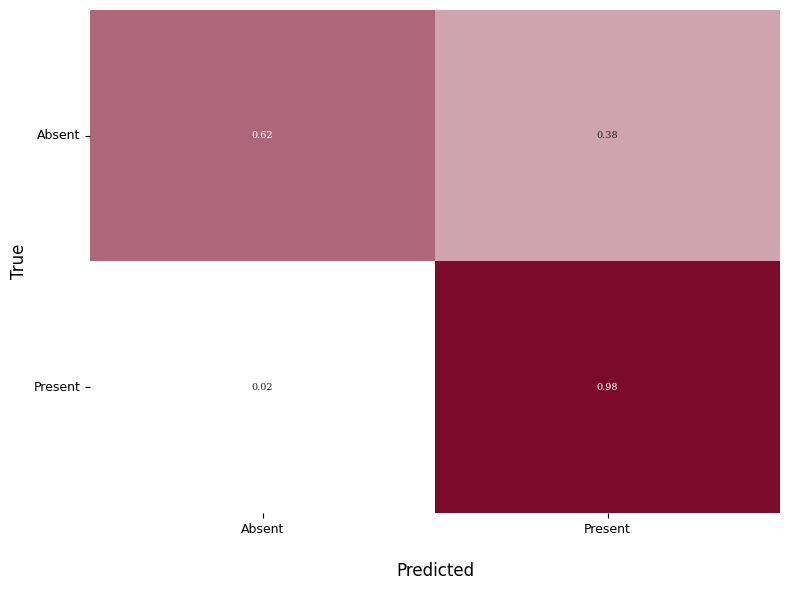

(92.01680672268907, 18.191259127404347)

In [39]:
# Final execution of the neuromorphic architecture test
test_model_accuracy(model, test_loader, device)

## 7. AutoML - Hyperparameter optimization (HPO) with Optuna

### ?

In [40]:
def snn_pedestrian_test_evaluation_loop(test_loader, net, device, draw_matrix=True):
    """
    Adapted from Fra, Vittorio; Politecnico di Torino; EDA Group.
    Comprehensive diagnostic testing loop computing multitask accuracy, localized IoU, 
    statistical chance level, and generating the evaluation confusion matrix.
    """
    net.eval()
    correct_cls = 0
    total_images = 0
    total_iou = 0.0
    true_positives_iou_count = 0  # To compute a mathematically rigorous average IoU
    
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for images, labels_cls, bboxes in tqdm(test_loader, desc="Testing Evaluation", leave=False):
            images = images.to(device)
            labels_cls = labels_cls.cpu()
            bboxes = bboxes.cpu()

            # Model prediction inference
            pred_cls, pred_bbox = net(images)
            pred_cls = pred_cls.cpu()
            pred_bbox = pred_bbox.cpu()

            # Convert continuous membrane potentials (logits) into binary choices
            preds_binary = (pred_cls >= 0.0).float()
            
            # Accumulate metrics
            correct_cls += (preds_binary == labels_cls).sum().item()
            total_images += images.size(0)

            # Record outputs for the confusion matrix calculation
            all_preds.extend(preds_binary.numpy())
            all_trues.extend(labels_cls.numpy())

            # Specific iterative bounding box spatial analysis
            for i in range(images.size(0)):
                if labels_cls[i] == 1.0 and preds_binary[i] == 1.0:
                    total_iou += calculate_iou(pred_bbox[i].tolist(), bboxes[i].tolist())
                    true_positives_iou_count += 1

    # Convert diagnostic lists to structured numpy arrays
    all_preds = np.array(all_preds)
    all_trues = np.array(all_trues)

    # Metric normalization computations
    cls_accuracy = (correct_cls / total_images) * 100
    avg_iou = (total_iou / true_positives_iou_count) * 100 if true_positives_iou_count > 0 else 0.0

    # Statistical Chance Level Evaluation (aligned with the Braille laboratory setup)
    _, counts = np.unique(all_trues, return_counts=True)
    most_frequent_class_count = counts[np.argmax(counts)]
    chance_level = (most_frequent_class_count / len(all_trues)) * 100

    # Display quantitative terminal summaries
    print("\n==================== TEST SPLIT RESULTS ====================")
    print(f"Total Evaluated Images:           {total_images}")
    print(f"Pedestrian Presence Accuracy:     {cls_accuracy:.4f}%")
    print(f"Statistical Chance Level:         {chance_level:.4f}%")
    print(f"Average Bounding Box IoU (on TP): {avg_iou:.4f}%")
    print("============================================================")

    # Automatic rendering of the operational confusion matrix
    if draw_matrix:
        # Custom descriptive binary label names for your specific task
        class_labels_description = ["Absent", "Present"]
        draw_confusion_matrix(
            all_preds,
            all_trues,
            class_labels_description
        )

    return [cls_accuracy, avg_iou, chance_level]

### ?

[I 2026-06-12 19:48:21,742] A new study created in memory with name: NMLOps_Pedestrian_HPO


Train batches: 238
Validation batches: 30
Test batches: 30

Running 3 Optuna trials (5 epochs each)...



  0%|          | 0/3 [00:00<?, ?it/s]

Trial 0 | Epoch 1/5: Val Loss: 5.6113 | Val Acc: 88.40%
Trial 0 | Epoch 2/5: Val Loss: 4.8435 | Val Acc: 89.66%
Trial 0 | Epoch 3/5: Val Loss: 4.8090 | Val Acc: 89.03%
Trial 0 | Epoch 4/5: Val Loss: 4.6862 | Val Acc: 89.87%
Trial 0 | Epoch 5/5: Val Loss: 4.7190 | Val Acc: 89.45%
[I 2026-06-12 19:49:39,221] Trial 0 finished with value: 0.8945147679324894 and parameters: {'shared_dim': 128, 'beta': 0.95, 'lr': 0.0017524101118128151}. Best is trial 0 with value: 0.8945147679324894.
Trial 1 | Epoch 1/5: Val Loss: 20.5127 | Val Acc: 81.86%
Trial 1 | Epoch 2/5: Val Loss: 13.4911 | Val Acc: 84.60%
Trial 1 | Epoch 3/5: Val Loss: 10.1600 | Val Acc: 90.30%
Trial 1 | Epoch 4/5: Val Loss: 8.3547 | Val Acc: 89.87%
Trial 1 | Epoch 5/5: Val Loss: 7.2807 | Val Acc: 90.08%
[I 2026-06-12 19:51:04,678] Trial 1 finished with value: 0.9008438818565401 and parameters: {'shared_dim': 192, 'beta': 0.55, 'lr': 0.00018408992080552527}. Best is trial 1 with value: 0.9008438818565401.
Trial 2 | Epoch 1/5: Val Los

Epoch 1/20: 
	training loss: 29.4655 
	validation loss: 21.9706 
	training accuracy: 81.2434% 
	validation accuracy: 77.6371%


...

Epoch 16/20: 
	training loss: 4.4202 
	validation loss: 4.7567 
	training accuracy: 92.6502% 
	validation accuracy: 90.0844%


Epoch 17/20: 
	training loss: 4.3304 
	validation loss: 4.6790 
	training accuracy: 92.4394% 
	validation accuracy: 89.8734%


Epoch 18/20: 
	training loss: 4.2026 
	validation loss: 4.6184 
	training accuracy: 92.5711% 
	validation accuracy: 90.0844%


Epoch 19/20: 
	training loss: 4.1265 
	validation loss: 4.5930 
	training accuracy: 92.7028% 
	validation accuracy: 90.2954%


Epoch 20/20: 
	training loss: 4.0790 
	validation loss: 4.5197 
	training accuracy: 92.8082% 
	validation accuracy: 90.5063%


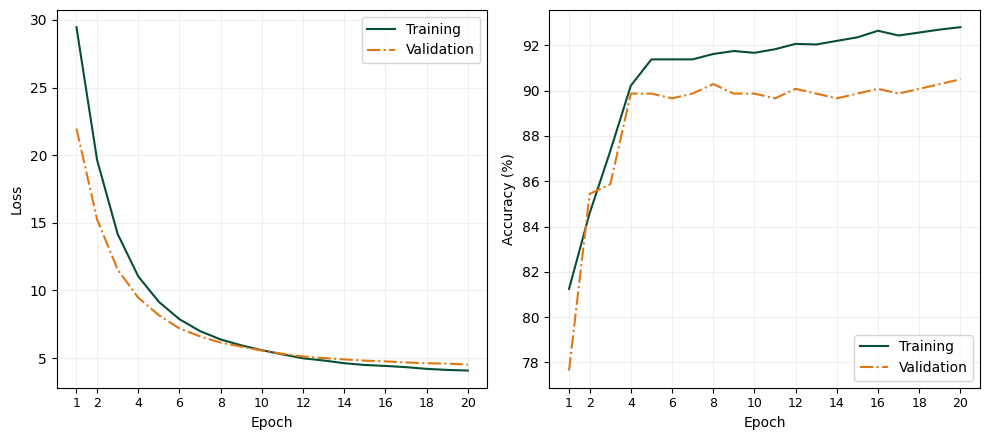


==================== TEST SPLIT RESULTS ====================
Total Evaluated Images:           476
Pedestrian Presence Accuracy:     92.2269%
Statistical Chance Level:         83.4034%
Average Bounding Box IoU (on TP): 22.8892%


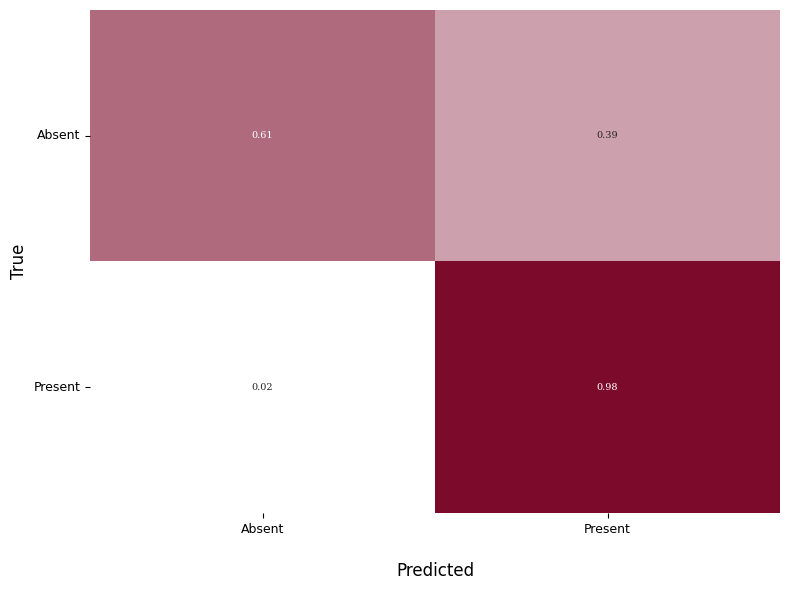


HPO Final Result Summary:
   -> Optimized Test Accuracy : 92.2269%
   -> Optimized Test IoU (TP) : 22.8892%


In [41]:
# 1. Unified HPO Optimization Functions (Multitask Aligned)
# -----------------------------------------------------------------------------
def snn_pedestrian_training_loop_hpo(data_loader, net, optimizer, criterion_cls, criterion_bbox, device):
    net.train()
    batch_losses = []
    batch_accs = []
    for images, labels_cls, bboxes in data_loader:
        images = images.to(device)
        labels_cls = labels_cls.to(device)
        bboxes = bboxes.to(device)

        pred_cls, pred_bbox = net(images)
        loss_cls = criterion_cls(pred_cls, labels_cls)
        loss_box = criterion_bbox(pred_bbox, bboxes)
        loss_val = loss_cls + 0.01 * loss_box
        batch_losses.append(loss_val.detach().cpu().item())

        preds_binary = (pred_cls >= 0.0).float()
        batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
    return [np.mean(batch_losses), np.mean(batch_accs)]


def snn_pedestrian_val_loop_hpo(data_loader, net, criterion_cls, criterion_bbox, device):
    net.eval()
    batch_losses = []
    batch_accs = []
    with torch.no_grad():
        for images, labels_cls, bboxes in data_loader:
            images = images.to(device)
            labels_cls = labels_cls.to(device)
            bboxes = bboxes.to(device)

            pred_cls, pred_bbox = net(images)
            loss_cls = criterion_cls(pred_cls, labels_cls)
            loss_box = criterion_bbox(pred_bbox, bboxes)
            loss_val = loss_cls + 0.01 * loss_box
            batch_losses.append(loss_val.detach().cpu().item())

            preds_binary = (pred_cls >= 0.0).float()
            batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())
    return [np.mean(batch_losses), np.mean(batch_accs)]


# 2. Optuna Objective Target Function
# -----------------------------------------------------------------------------
def objective(trial: optuna.Trial, device=device) -> float:
    """
    Returns validation accuracy for HPO experiments through Optuna on PedestrianSNN.
    """
    # Define the search space dynamically updating our unified settings dictionary
    snn_settings["shared_dim"] = trial.suggest_int("shared_dim", 64, 256, step=64)
    snn_settings["beta"]       = trial.suggest_float("beta", 0.5, 0.95, step=0.05)
    lr                         = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    # Re-instantiate the model dynamically with the trial settings
    model = PedestrianSNN(num_steps=num_steps, settings=snn_settings).to(device)

    criterion_cls = nn.BCEWithLogitsLoss()
    criterion_bbox = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    pedestrian_validation_results = []

    for epoch in range(N_EPOCHS_HPO):
        _ = snn_pedestrian_training_loop_hpo(
            train_loader, model, optimizer, criterion_cls, criterion_bbox, device
        )
        val_loss, val_acc = snn_pedestrian_val_loop_hpo(
            val_loader, model, criterion_cls, criterion_bbox, device
        )
        pedestrian_validation_results.append([val_loss, val_acc])

        print(f"Trial {trial.number} | Epoch {epoch+1}/{N_EPOCHS_HPO}: "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    return pedestrian_validation_results[-1][1] # Return the final epoch accuracy for optimization


# 3. Execution of the Search Study
# -----------------------------------------------------------------------------
N_TRIALS = 3
N_EPOCHS_HPO = 5
SEED_HPO = 42

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED_HPO),
    study_name="NMLOps_Pedestrian_HPO"
)

print(f"Running {N_TRIALS} Optuna trials ({N_EPOCHS_HPO} epochs each)...\n")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# Summary of best trial
best = study.best_trial
print(f"\n{'='*55}")
print(f"  Best trial: #{best.number}")
print(f"  Validation accuracy: {best.value*100:.2f}%")
print(f"  Optimal hyperparameters found:")
for k, v in best.params.items():
    print(f"    {k:<15} = {v}")
print(f"{'='*55}\n")


# 4. Retraining the Optimal Network Architecture configuration
# -----------------------------------------------------------------------------
snn_settings["shared_dim"] = best.params["shared_dim"]
snn_settings["beta"]       = best.params["beta"]

optimal_pedestrian_net = PedestrianSNN(num_steps=num_steps, settings=snn_settings).to(device)

FULL_EPOCHS = 20
print(f"Retraining the best configuration for {FULL_EPOCHS} epochs.\n")

criterion_cls = nn.BCEWithLogitsLoss()
criterion_bbox = nn.MSELoss()
optimizer = torch.optim.Adam(optimal_pedestrian_net.parameters(), lr=best.params["lr"])

pedestrian_training_results = []
pedestrian_validation_results = []

for epoch in range(FULL_EPOCHS):
    train_loss, train_acc = snn_pedestrian_training_loop(
        train_loader, optimal_pedestrian_net, optimizer, criterion_cls, criterion_bbox, device
    )
    val_loss, val_acc = snn_pedestrian_val_test_loop(
        val_loader, optimal_pedestrian_net, criterion_cls, criterion_bbox, device
    )

    pedestrian_training_results.append([train_loss, train_acc])
    pedestrian_validation_results.append([val_loss, val_acc])

    print(f"Epoch {epoch+1}/{FULL_EPOCHS}: \n"
          f"\ttraining loss: {pedestrian_training_results[-1][0]:.4f} \n"
          f"\tvalidation loss: {pedestrian_validation_results[-1][0]:.4f} \n"
          f"\ttraining accuracy: {np.round(pedestrian_training_results[-1][1]*100,4)}% \n"
          f"\tvalidation accuracy: {np.round(pedestrian_validation_results[-1][1]*100,4)}%")

# Generate performance graphs
learning_curves(
    np.array(pedestrian_training_results)[:,0],    # training loss
    np.array(pedestrian_validation_results)[:,0],  # validation loss
    np.array(pedestrian_training_results)[:,1],    # training accuracy
    np.array(pedestrian_validation_results)[:,1]   # validation accuracy
)

print("\n\n")

# Evaluate final performance on the Test split using the custom function defined previously
final_test_results = snn_pedestrian_test_evaluation_loop(
    test_loader, optimal_pedestrian_net, device, draw_matrix=True
)

print("\nHPO Final Result Summary:")
print(f"   -> Optimized Test Accuracy : {np.round(final_test_results[0], 4)}%")
print(f"   -> Optimized Test IoU (TP) : {np.round(final_test_results[1], 4)}%")